In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
import numpy as np

In [104]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [105]:
df = pd.read_csv('TH3/data/MarketingCampaign.csv', sep='\t')


In [106]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [107]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [108]:
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)


         ID  Year_Birth   Education Marital_Status  Income  Kidhome  Teenhome  \
10     1994        1983  Graduation        Married     NaN        1         0   
27     5255        1986  Graduation         Single     NaN        1         0   
43     7281        1959         PhD         Single     NaN        0         0   
48     7244        1951  Graduation         Single     NaN        2         1   
58     8557        1982  Graduation         Single     NaN        1         0   
71    10629        1973    2n Cycle        Married     NaN        1         0   
90     8996        1957         PhD        Married     NaN        2         1   
91     9235        1957  Graduation         Single     NaN        1         1   
92     5798        1973      Master       Together     NaN        0         0   
128    8268        1961         PhD        Married     NaN        0         1   
133    1295        1963  Graduation        Married     NaN        0         1   
312    2437        1989  Gra

In [109]:
df_cleaned = df.dropna(subset=['Income'])

In [110]:
print(df_cleaned['Education'].value_counts())
print(df_cleaned['Marital_Status'].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [111]:
keep_status = ['Married', 'Together', 'Single', 'Divorced']

# Thay thế các giá trị không nằm trong danh sách trên thành 'Other'
df_cleaned['Marital_Status'] = df_cleaned['Marital_Status'].apply(lambda x: x if x in keep_status else 'Other')

print(df_cleaned['Marital_Status'].value_counts())

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Other        83
Name: count, dtype: int64


In [112]:
from datetime import datetime

# Lấy năm hiện tại (hệ thống)
current_year = 2010

# Tạo cột Tuổi (Age)
df_cleaned['Age'] = current_year - df_cleaned['Year_Birth']

In [113]:
df_cleaned['Age'].max()

117

In [114]:
df_cleaned['Age'].min()

14

(array([ 43., 144., 193., 309., 388., 290., 287., 246., 207.,  91.,  15.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   1.]),
 array([ 14.  ,  19.15,  24.3 ,  29.45,  34.6 ,  39.75,  44.9 ,  50.05,
         55.2 ,  60.35,  65.5 ,  70.65,  75.8 ,  80.95,  86.1 ,  91.25,
         96.4 , 101.55, 106.7 , 111.85, 117.  ]),
 <BarContainer object of 20 artists>)

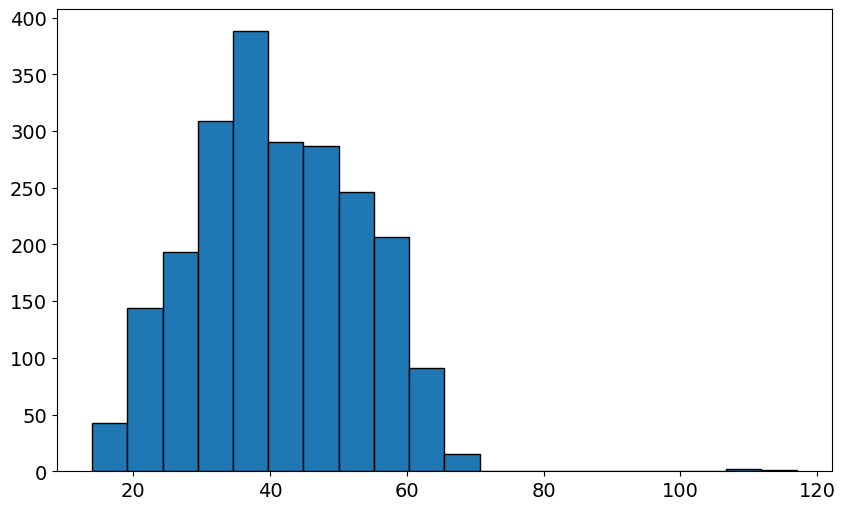

In [115]:
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['Age'], bins=20, edgecolor='black')


In [116]:
# TẠO CỘT TOTAL_KID 
df_cleaned['Total_Kid'] = df_cleaned['Kidhome'] + df_cleaned['Teenhome']
print(df_cleaned['Total_Kid'].value_counts().sort_index())

Total_Kid
0     633
1    1117
2     416
3      50
Name: count, dtype: int64


In [117]:
#  TẠO CỘT TỔNG SỐ LƯỢT MUA HÀNG (Total_Purchases)
purchases_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_cleaned['Total_Purchases'] = df_cleaned[purchases_cols].sum(axis=1)

#  TẠO CỘT TỔNG SỐ LẦN TƯƠNG TÁC KHUYẾN MÃI (Total_Promos)
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_cleaned['Total_Promos'] = df_cleaned[cmp_cols].sum(axis=1)

In [118]:
print(df_cleaned['Z_CostContact'].value_counts())
print(df_cleaned['Z_Revenue'].value_counts())

Z_CostContact
3    2216
Name: count, dtype: int64
Z_Revenue
11    2216
Name: count, dtype: int64


In [119]:
df_cleaned.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Kid', 'Total_Purchases', 'Total_Promos'],
      dtype='str')

In [120]:
col_collections = ['Age', 'Education', 'Marital_Status', 'Complain' 
                   ,'Income', 'Kidhome','Recency','Total_Kid', 'Total_Purchases', 'Total_Promos',
                    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']


In [121]:
df_collections = df_cleaned[col_collections]

In [122]:
df_collections.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2216 non-null   int64  
 1   Education         2216 non-null   str    
 2   Marital_Status    2216 non-null   str    
 3   Complain          2216 non-null   int64  
 4   Income            2216 non-null   float64
 5   Kidhome           2216 non-null   int64  
 6   Recency           2216 non-null   int64  
 7   Total_Kid         2216 non-null   int64  
 8   Total_Purchases   2216 non-null   int64  
 9   Total_Promos      2216 non-null   int64  
 10  MntWines          2216 non-null   int64  
 11  MntFruits         2216 non-null   int64  
 12  MntMeatProducts   2216 non-null   int64  
 13  MntFishProducts   2216 non-null   int64  
 14  MntSweetProducts  2216 non-null   int64  
 15  MntGoldProds      2216 non-null   int64  
dtypes: float64(1), int64(13), str(2)
memory usage: 326.2 KB


In [123]:
df_collections.head()


,Age,Education,Marital_Status,Complain,Income,Kidhome,Recency,Total_Kid,Total_Purchases,Total_Promos,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,53,Graduation,Single,0,58138.0,0,58,0,25,1,635,88,546,172,88,88
1,56,Graduation,Single,0,46344.0,1,38,2,6,0,11,1,6,2,1,6
2,45,Graduation,Together,0,71613.0,0,26,0,21,0,426,49,127,111,21,42
3,26,Graduation,Together,0,26646.0,1,26,1,8,0,11,4,20,10,3,5
4,29,PhD,Married,0,58293.0,1,94,1,19,0,173,43,118,46,27,15


In [124]:
# Định nghĩa thứ tự học vấn từ thấp đến cao
edu_order = {
    'Basic': 1,
    'Graduation': 2,
    '2n Cycle': 3,
    'Master': 4,
    'PhD': 5
}

# Thay thế chữ bằng số vào thẳng cột Education
df_collections['Education'] = df_collections['Education'].map(edu_order)

# ==========================================
# ONE-HOT ENCODING CHO 'Marital_Status' (Không có thứ tự)
# ==========================================
# (Tùy chọn) Gom các nhóm quá nhỏ lại thành 'Other' nếu bạn chưa làm ở bước trước
keep_status = ['Married', 'Together', 'Single', 'Divorced']
df_collections['Marital_Status'] = df_collections['Marital_Status'].apply(lambda x: x if x in keep_status else 'Other')

# Mã hóa One-Hot cho Marital_Status và lưu vào biến mới df_encoded
df_encoded = pd.get_dummies(df_collections, columns=['Marital_Status'], dtype=int)

# --- IN THỬ KẾT QUẢ ĐỂ KIỂM TRA ---
print(df_encoded.head())

   Age  Education  Complain   Income  Kidhome  Recency  Total_Kid  \
0   53          2         0  58138.0        0       58          0   
1   56          2         0  46344.0        1       38          2   
2   45          2         0  71613.0        0       26          0   
3   26          2         0  26646.0        1       26          1   
4   29          5         0  58293.0        1       94          1   

   Total_Purchases  Total_Promos  MntWines  MntFruits  MntMeatProducts  \
0               25             1       635         88              546   
1                6             0        11          1                6   
2               21             0       426         49              127   
3                8             0        11          4               20   
4               19             0       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  Marital_Status_Divorced  \
0              172                88            88           

In [125]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      2216 non-null   int64  
 1   Education                2216 non-null   int64  
 2   Complain                 2216 non-null   int64  
 3   Income                   2216 non-null   float64
 4   Kidhome                  2216 non-null   int64  
 5   Recency                  2216 non-null   int64  
 6   Total_Kid                2216 non-null   int64  
 7   Total_Purchases          2216 non-null   int64  
 8   Total_Promos             2216 non-null   int64  
 9   MntWines                 2216 non-null   int64  
 10  MntFruits                2216 non-null   int64  
 11  MntMeatProducts          2216 non-null   int64  
 12  MntFishProducts          2216 non-null   int64  
 13  MntSweetProducts         2216 non-null   int64  
 14  MntGoldProds             2216 non-null  

In [126]:
df_encoded.head().to_csv('view.csv', index=False)

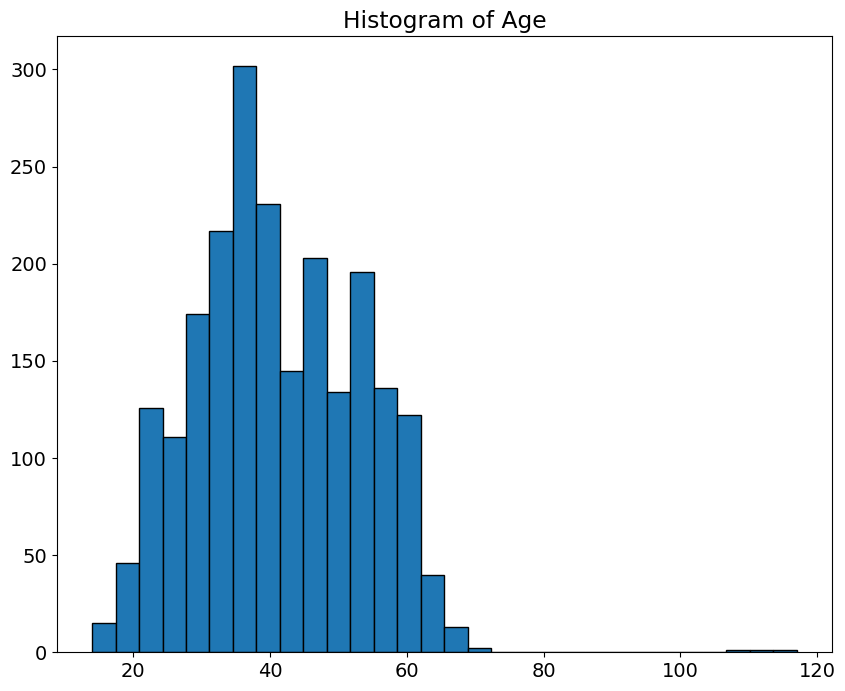

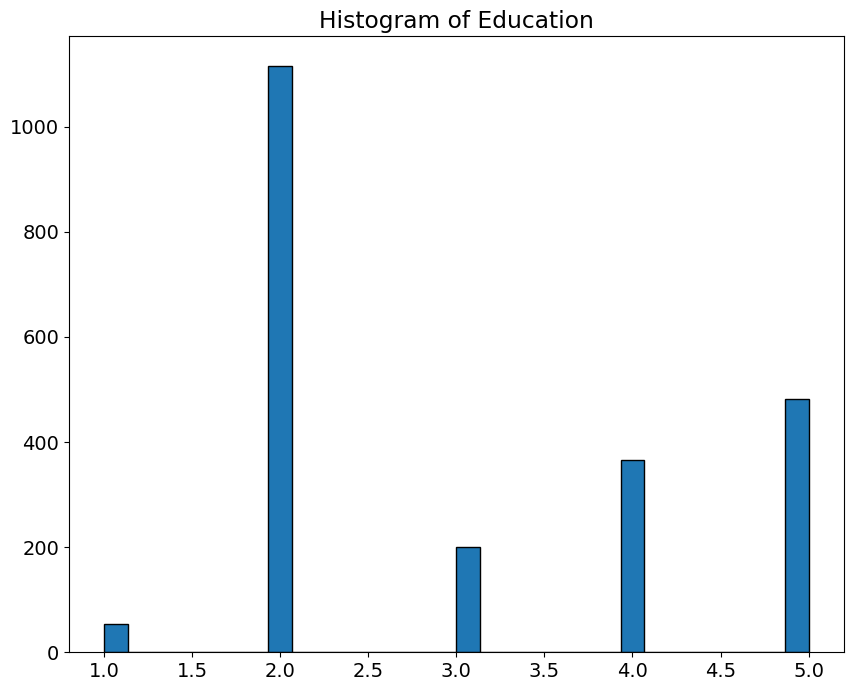

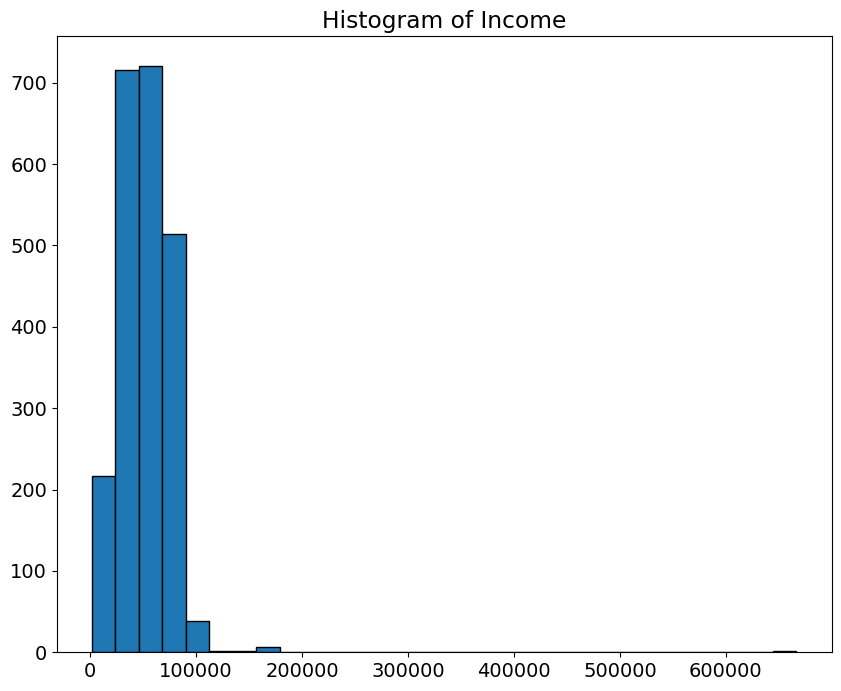

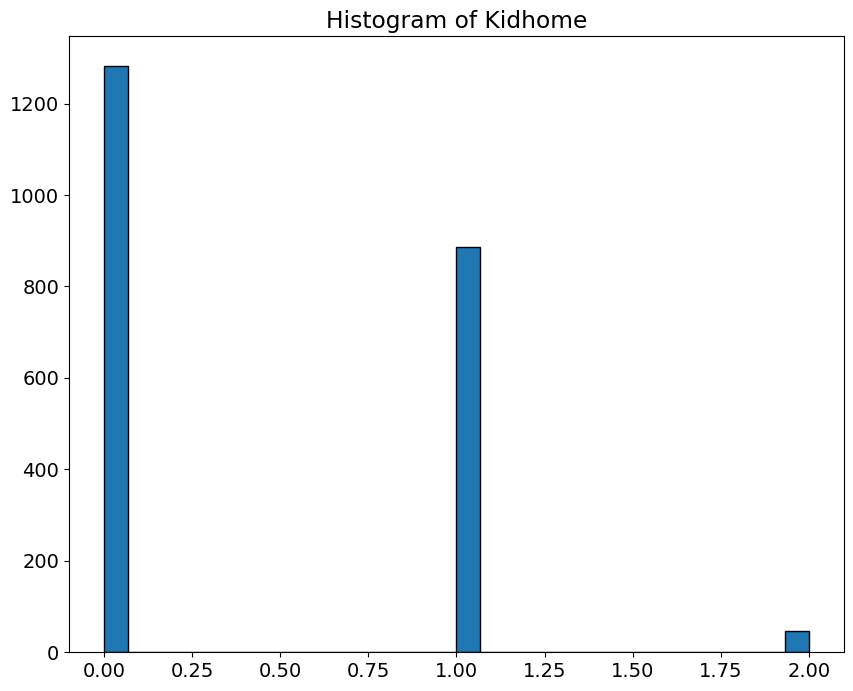

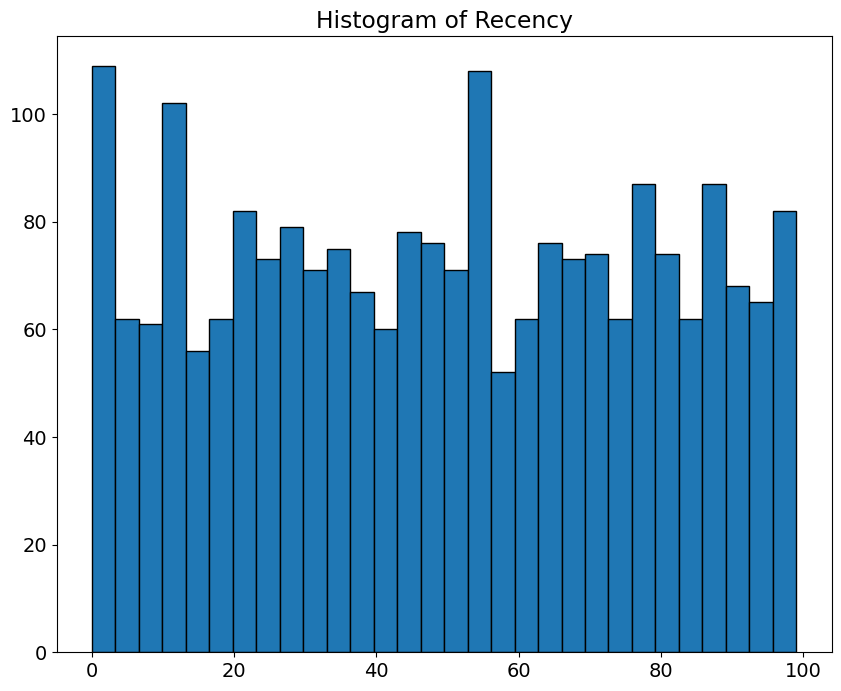

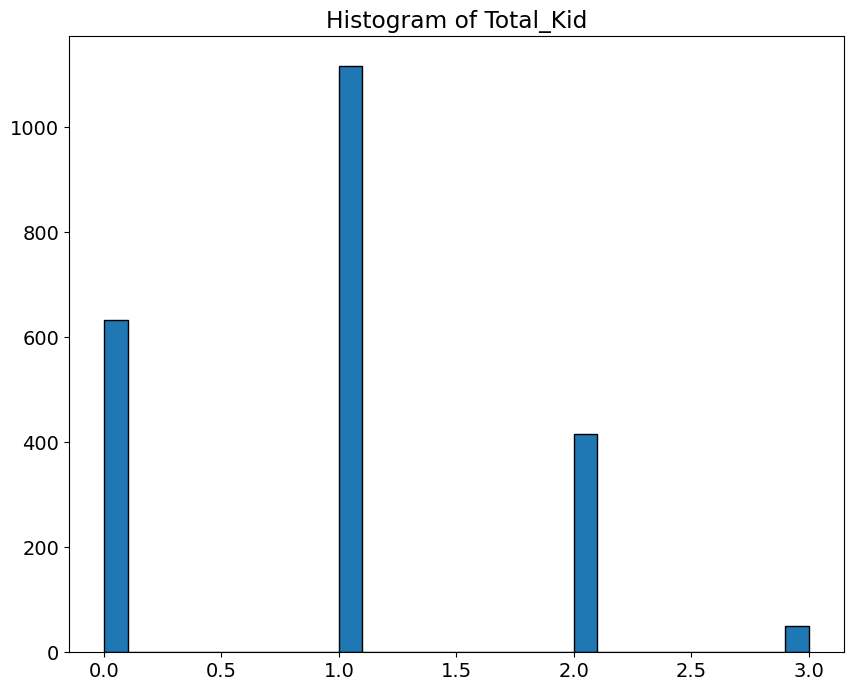

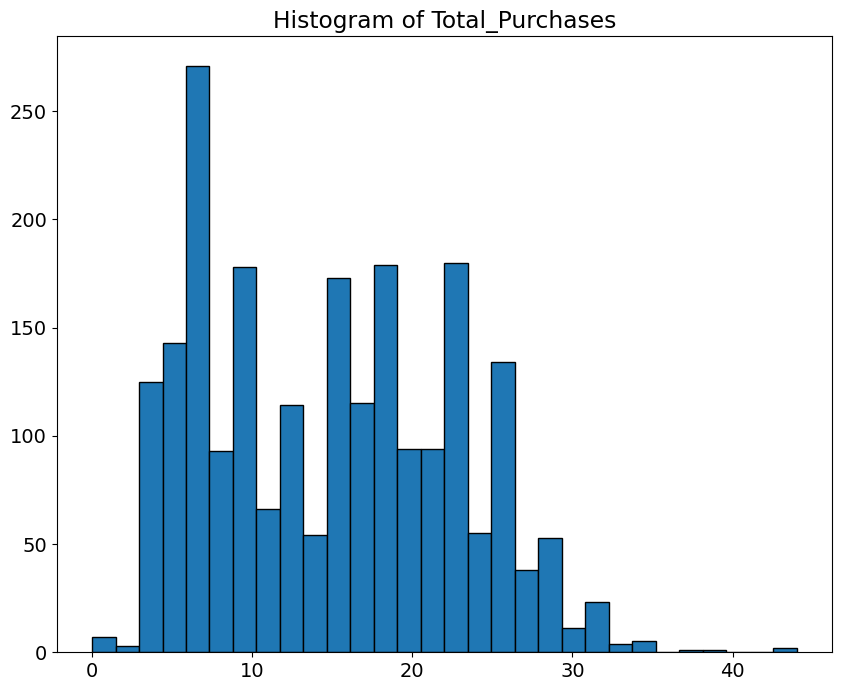

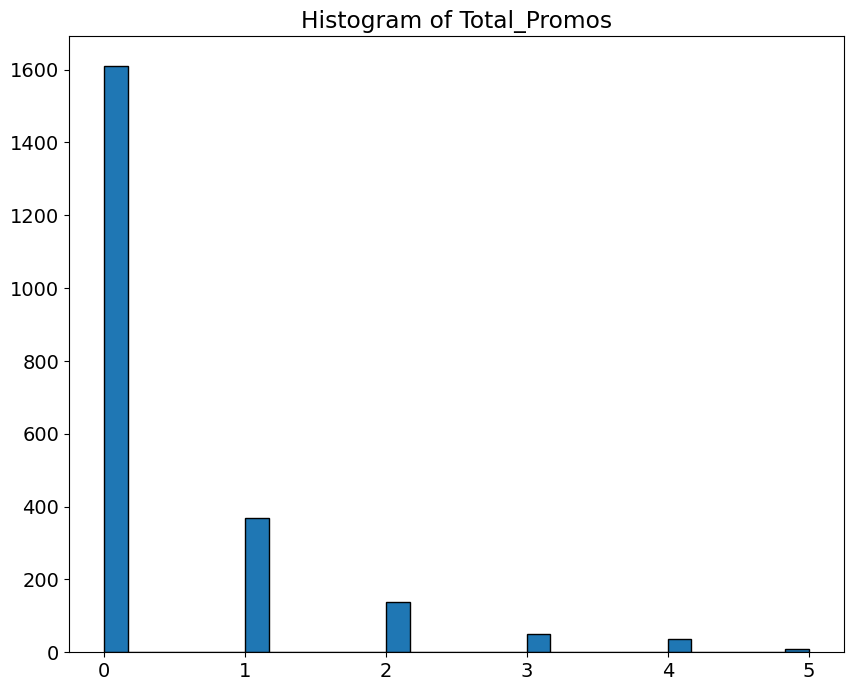

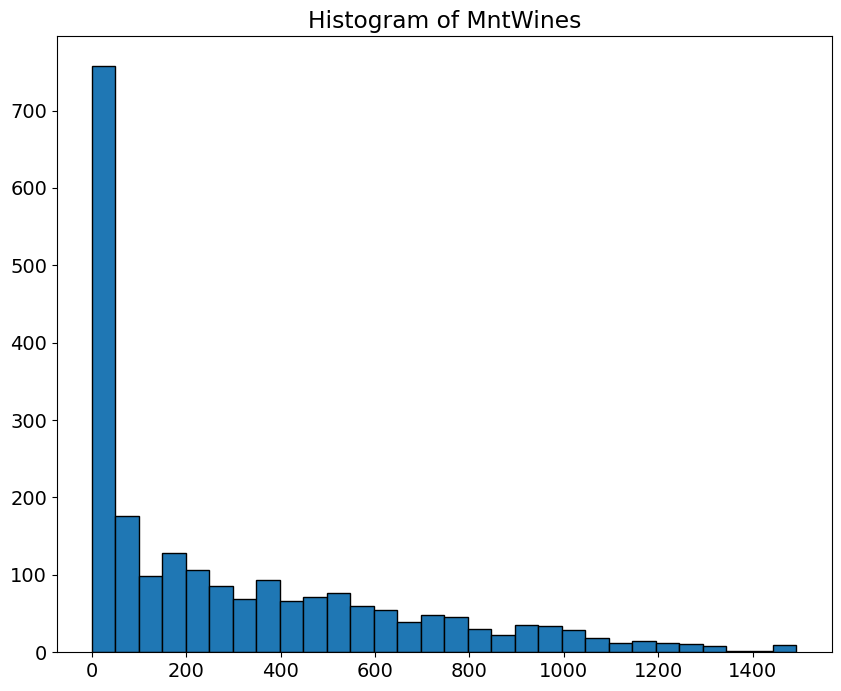

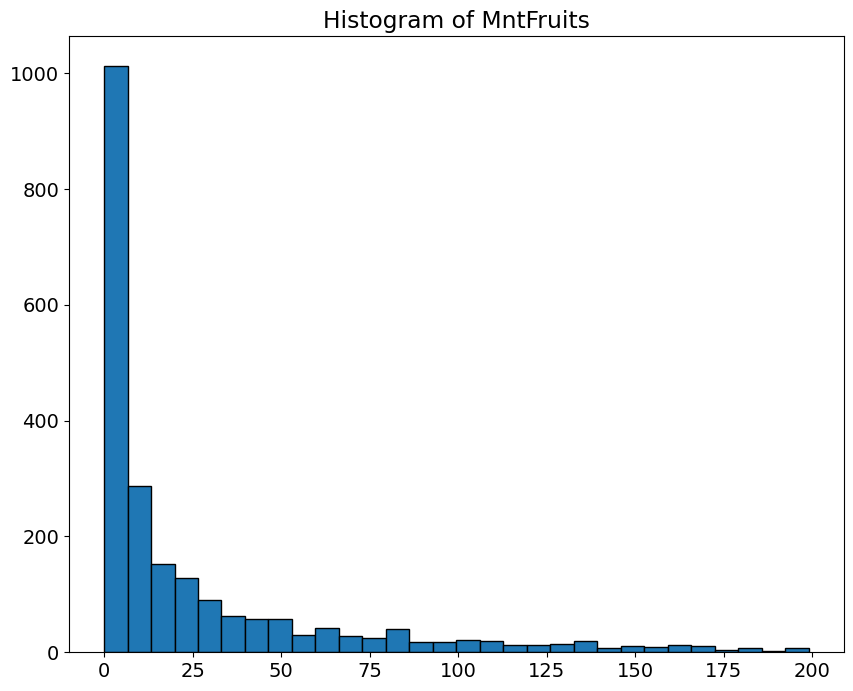

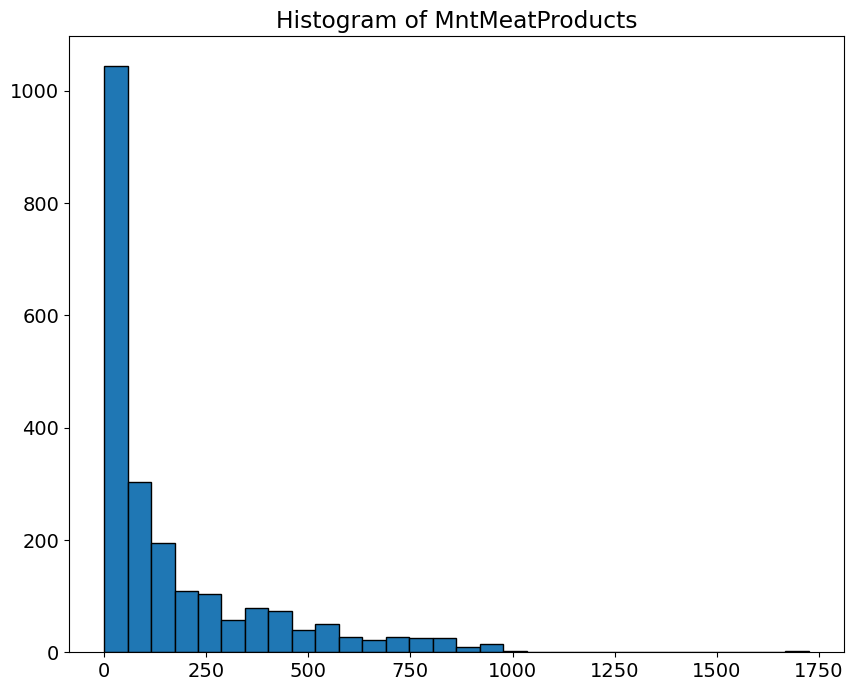

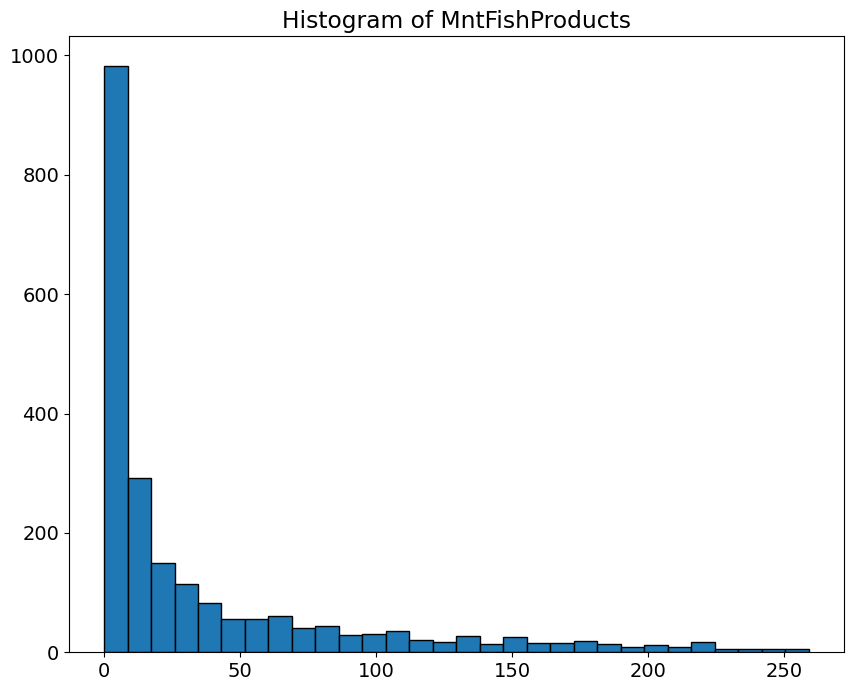

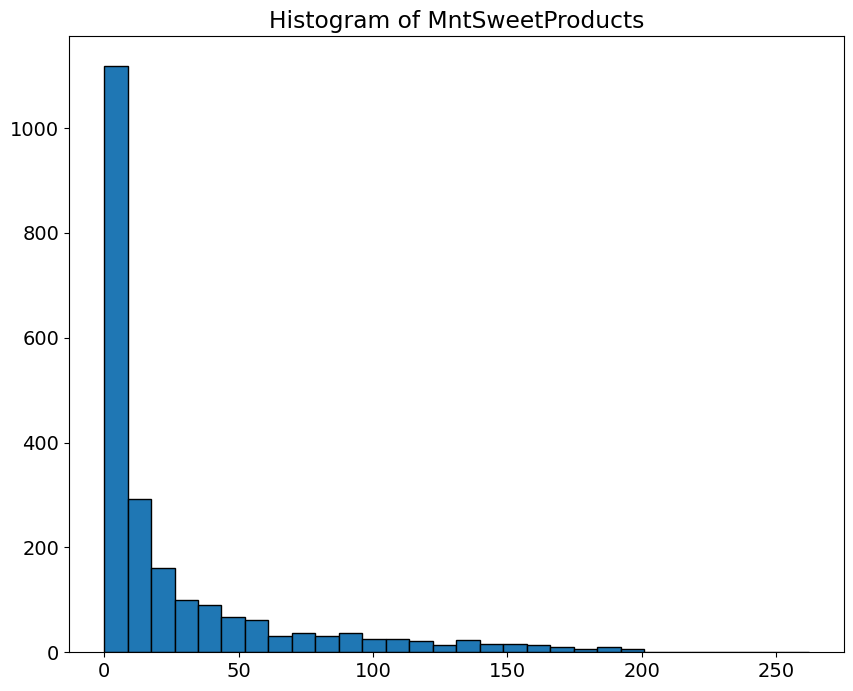

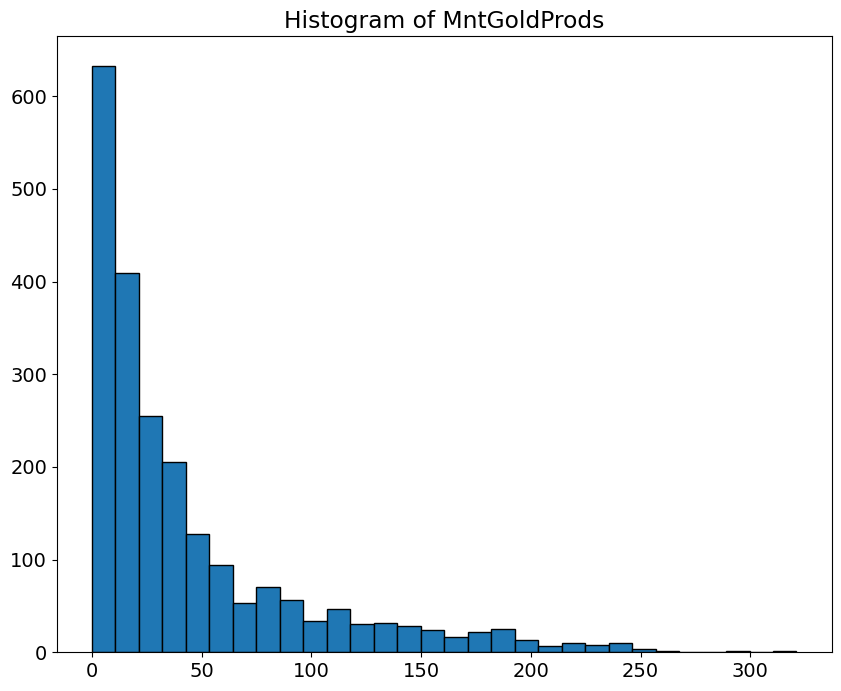

In [127]:
num_cols = ['Age','Education', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

for col in num_cols:
    plt.hist(df_encoded[col], bins=30, edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.show()


In [128]:
# Giả sử 'df' là DataFrame dữ liệu của bạn đã được làm sạch và tạo biến
num_cols = ['Age','Education', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 
            'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 
            'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Tính chỉ số Skewness và sắp xếp từ cao xuống thấp để dễ nhìn
skewness_values = df_encoded[num_cols].skew().sort_values(ascending=False)

print("--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) CỦA CÁC BIẾN ---")
print(skewness_values)

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) CỦA CÁC BIẾN ---
Income              6.763487
Total_Promos        2.440020
MntSweetProducts    2.103328
MntFruits           2.101658
MntMeatProducts     2.025577
MntFishProducts     1.916369
MntGoldProds        1.839231
MntWines            1.170720
Kidhome             0.635610
Education           0.468014
Total_Kid           0.408748
Age                 0.353661
Total_Purchases     0.250936
Recency             0.001648
dtype: float64


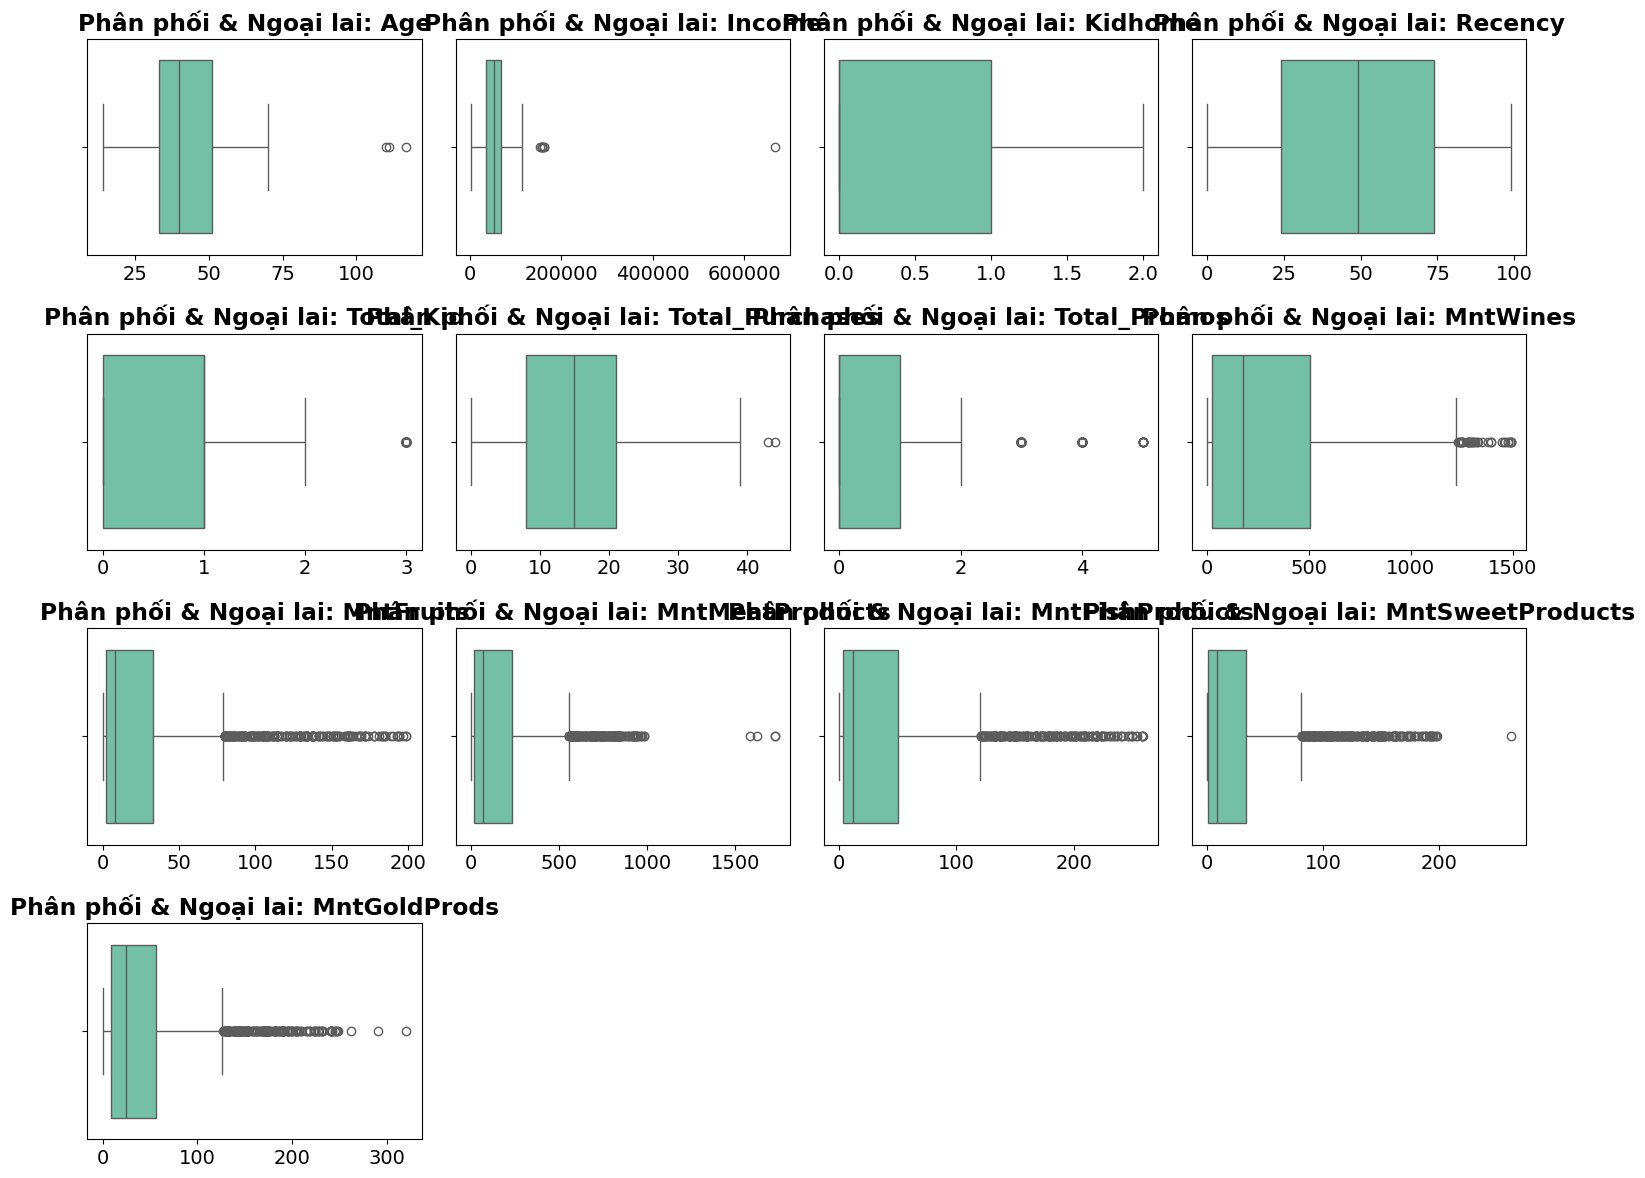

In [129]:
num_cols = ['Age', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

# Tạo khung vẽ gồm nhiều đồ thị con (3 hàng, 3 cột cho đẹp)x
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Dùng orient='h' để vẽ hộp nằm ngang cho dễ nhìn, hoặc 'v' (mặc định) cho hộp nằm dọc
    sns.boxplot(x=df_encoded[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Phân phối & Ngoại lai: {col}', fontweight='bold')
    axes[i].set_xlabel('')

# Xóa các ô trống không dùng đến (vì có 13 biến nhưng có 16 ô)
for j in range(13, 16):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [130]:
df_encoded.columns

Index(['Age', 'Education', 'Complain', 'Income', 'Kidhome', 'Recency',
       'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Other', 'Marital_Status_Single',
       'Marital_Status_Together'],
      dtype='str')

In [131]:
# # CHuẩn hóa 
from sklearn.preprocessing import StandardScaler, RobustScaler
right_cols = [ 'Income', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
norm_cols = ['Age', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases','Education']

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_encoded)

In [132]:

std_scaler = StandardScaler()


X_scaled = df_encoded.copy()
# Fit và Transform cho từng nhóm cột

# Bước A: Ép hình dáng đuôi dài về dạng hình chuông (Log Transformation) 
X_scaled[right_cols] = np.log1p(X_scaled[right_cols])
# Bước B: Đồng bộ thang đo (StandardScaler) sau khi đã có hình chuông
X_scaled[right_cols] = std_scaler.fit_transform(X_scaled[right_cols])

# Áp dụng StandardScaler cho nhóm phân phối chuẩn
X_scaled[norm_cols] = std_scaler.fit_transform(X_scaled[norm_cols])





In [133]:
# --- KIỂM TRA KẾT QUẢ ---
print("Dữ liệu sau khi Scale bằng 2 phương pháp khác nhau:")
print(X_scaled.head())

Dữ liệu sau khi Scale bằng 2 phương pháp khác nhau:
        Age  Education  Complain    Income   Kidhome   Recency  Total_Kid  \
0  0.986443  -0.819198         0  0.428623 -0.823039  0.310532  -1.264803   
1  1.236801  -0.819198         0 -0.019686  1.039938 -0.380509   1.405806   
2  0.318822  -0.819198         0  0.840808 -0.823039 -0.795134  -1.264803   
3 -1.266777  -0.819198         0 -1.114019  1.039938 -0.795134   0.070501   
4 -1.016420   1.529240         0  0.433888  1.039938  1.554407   0.070501   

   Total_Purchases  Total_Promos  MntWines  MntFruits  MntMeatProducts  \
0         1.319446      1.005640  0.984704   1.430700         1.393131   
1        -1.157987     -0.568991 -1.214599  -0.987662        -1.398987   
2         0.797881     -0.568991  0.764006   1.063301         0.462699   
3        -0.897205     -0.568991 -1.214599  -0.403832        -0.695206   
4         0.537099     -0.568991  0.266718   0.981849         0.415994   

   MntFishProducts  MntSweetProducts  Mn

In [134]:
# # 2. Khởi tạo Scaler
# scaler = StandardScaler()

# # 3. Tạo một bản sao của DataFrame để không làm hỏng dữ liệu gốc
# X_scaled = df_encoded.copy()

# # 4. Chỉ chuẩn hóa đúng các cột số và ghi đè lại vào df_scaled
# X_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [135]:
X_scaled

,Age,Education,Complain,Income,Kidhome,Recency,Total_Kid,Total_Purchases,Total_Promos,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,0.986443,-0.819198,0,0.428623,-0.823039,0.310532,-1.264803,1.319446,1.005640,0.984704,1.430700,1.393131,1.578200,1.411177,1.061557,0,0,0,1,0
1,1.236801,-0.819198,0,-0.019686,1.039938,-0.380509,1.405806,-1.157987,-0.568991,-1.214599,-0.987662,-1.398987,-0.869044,-0.972475,-0.913938,0,0,0,1,0
2,0.318822,-0.819198,0,0.840808,-0.823039,-0.795134,-1.264803,0.797881,-0.568991,0.764006,1.063301,0.462699,1.315777,0.533457,0.496397,0,0,0,0,1
3,-1.266777,-0.819198,0,-1.114019,1.039938,-0.795134,0.070501,-0.897205,-0.568991,-1.214599,-0.403832,-0.695206,-0.084848,-0.537163,-1.033701,0,0,0,0,1
4,-1.016420,1.529240,0,0.433888,1.039938,1.554407,0.070501,0.537099,-0.568991,0.266718,0.981849,0.415994,0.791674,0.684912,-0.271675,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.151917,-0.819198,0,0.530857,-0.823039,-0.104093,0.070501,0.406708,-0.568991,1.045674,0.981849,0.691689,0.737989,1.593610,1.857739,0,1,0,0,0
2236,1.904422,1.529240,0,0.619003,2.902916,0.241428,2.741110,0.928273,1.005640,0.737433,-1.429313,-0.445712,-1.532123,-1.407787,-0.718687,0,0,0,0,1
2237,-1.016420,-0.819198,0,0.388876,-0.823039,1.450751,-1.264803,0.537099,1.005640,1.182541,1.050428,0.803801,0.578231,0.203058,0.075054,1,0,0,0,0
2238,1.069896,0.746428,0,0.774319,-0.823039,-1.417072,0.070501,1.058664,-0.568991,0.766594,0.758712,0.794924,1.120193,0.748834,0.780699,0,0,0,0,1


In [136]:

from sklearn.cluster import KMeans


inertia = []
K_range = range(1, 11) # Khảo sát số cụm từ 1 đến 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # Chạy thuật toán trên không gian dữ liệu đã giảm chiều PCA
    inertia.append(kmeans.inertia_)



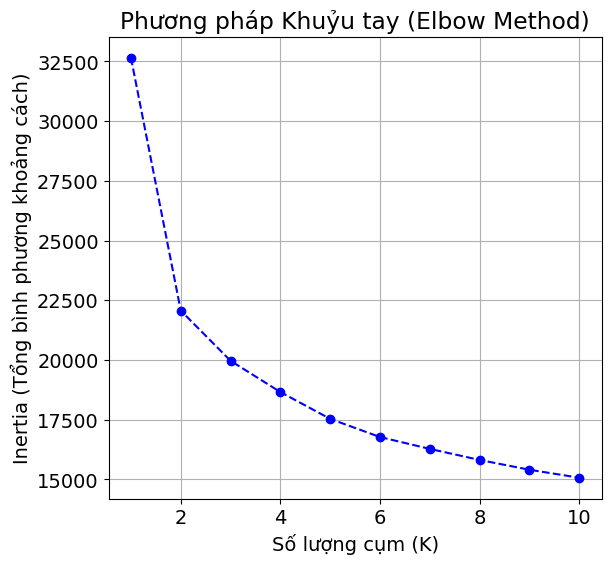

In [137]:
# --- BƯỚC 4: VẼ BIỂU ĐỒ TRỰC QUAN HÓA ---
plt.figure(figsize=(14, 6))

# Đồ thị 1: Phương pháp Khuỷu tay (Elbow)
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Inertia (Tổng bình phương khoảng cách)')
plt.title('Phương pháp Khuỷu tay (Elbow Method)')
plt.grid(True)

In [138]:

from sklearn.metrics import silhouette_score


silhouette_scores = []
K_range_sil = range(2, 12) 

# Chạy vòng lặp tính Silhouette Score cho từng K
for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Tính điểm Silhouette
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)


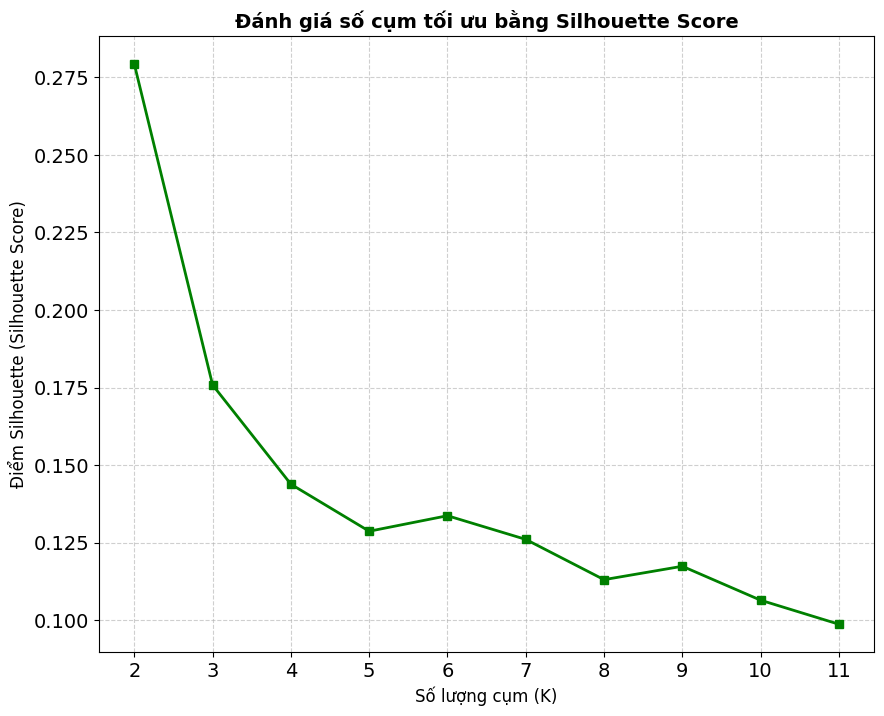

In [139]:

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
plt.plot(K_range_sil, silhouette_scores, marker='s', linestyle='-', color='green', linewidth=2)

plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('Điểm Silhouette (Silhouette Score)', fontsize=12)
plt.title('Đánh giá số cụm tối ưu bằng Silhouette Score', fontsize=14, fontweight='bold')
plt.xticks(K_range_sil)
plt.grid(True, linestyle='--', alpha=0.6)

In [140]:
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X_scaled)



In [141]:
cluster_labels  

array([2, 1, 2, ..., 2, 2, 0])

In [142]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

## PCA : đã mã hóa định tính 
- PCA về bản chất là phương pháp chỉ dành cho biến định lượng. Nó làm việc trên phương sai, hiệp phương sai và khoảng cách Euclid — những đại lượng chỉ có ý nghĩa với số liên tục.
- PCA không phân biệt được loại biến. Phương sai của biến  định lượng không mang cùng ý nghĩa mà PCA làm việc.
- vô tình phương sai của biến định tính đã được one_hot bị xem nhẹ. dễ bị cắt mất khi giảm chiều.
- FAMD — phiên bản mở rộng của PCA 

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


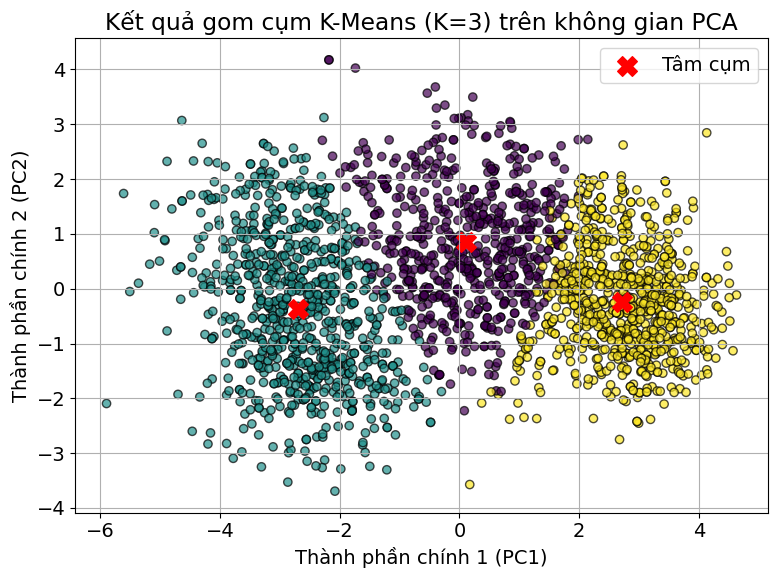

In [143]:
# Chiếu tâm cụm vào không gian PCA
centers_pca = pca.transform(kmeans_optimal.cluster_centers_)


fig = plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='k')

plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            s=200, c='red', marker='X', label='Tâm cụm')

plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.title(f'Kết quả gom cụm K-Means (K={optimal_k}) trên không gian PCA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

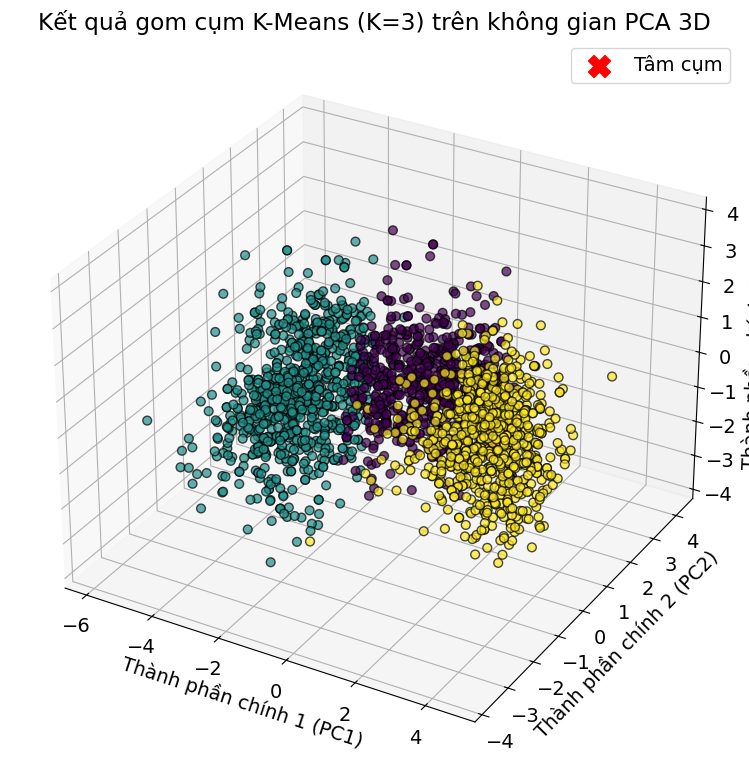

In [144]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                     c=cluster_labels, cmap='viridis', 
                     alpha=0.7, edgecolors='k', s=40)

# SỬA: dùng centers_pca
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], centers_pca[:, 2], 
           s=250, c='red', marker='X', label='Tâm cụm')

ax.set_xlabel('Thành phần chính 1 (PC1)')
ax.set_ylabel('Thành phần chính 2 (PC2)')
ax.set_zlabel('Thành phần chính 3 (PC3)')
ax.set_title(f'Kết quả gom cụm K-Means (K={optimal_k}) trên không gian PCA 3D')
ax.legend()
plt.tight_layout()
plt.show()


--- SỐ LƯỢNG KHÁCH HÀNG TỪNG CỤM ---
0    595
1    827
2    794
Name: count, dtype: int64


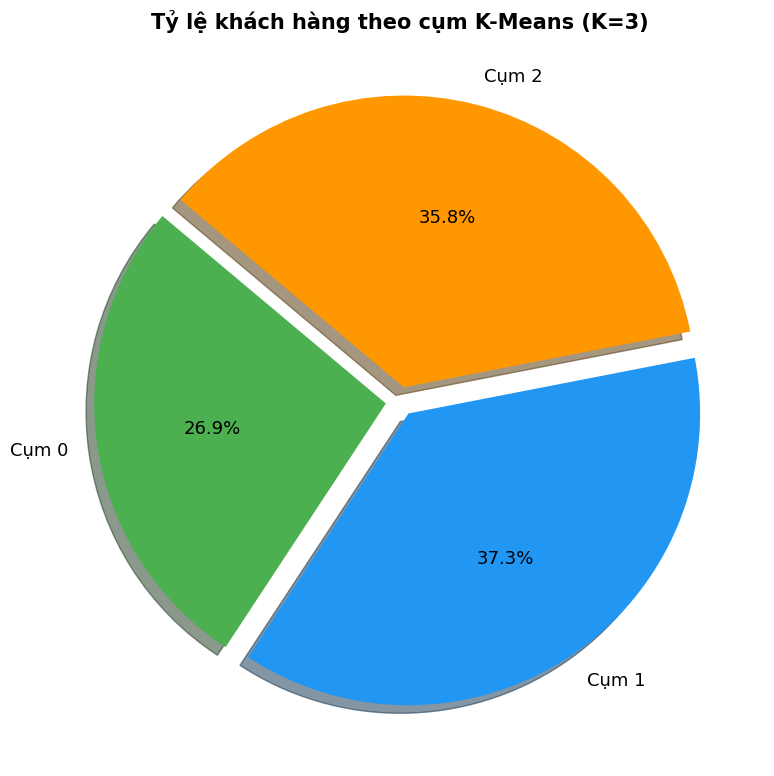


--- SỐ LƯỢNG KHÁCH HÀNG TỪNG CỤM ---
  Cụm 0: 595 khách hàng (26.9%)
  Cụm 1: 827 khách hàng (37.3%)
  Cụm 2: 794 khách hàng (35.8%)


In [145]:
# ĐẾM SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI CỤM
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\n--- SỐ LƯỢNG KHÁCH HÀNG TỪNG CỤM ---")
print(cluster_counts)
labels = [f'Cụm {i}' for i in cluster_counts.index]
sizes  = cluster_counts.values
colors = ['#4CAF50', '#2196F3', '#FF9800']   # xanh lá, xanh dương, cam
explode = [0.05] * optimal_k                  # tách nhẹ mỗi miếng ra ngoài

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',      # hiện phần trăm
    startangle=140,
    shadow=True,
    textprops={'fontsize': 13}
)
plt.title(f'Tỷ lệ khách hàng theo cụm K-Means (K={optimal_k})',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# IN THÊM SỐ TUYỆT ĐỐI ĐỂ THAM KHẢO
print("\n--- SỐ LƯỢNG KHÁCH HÀNG TỪNG CỤM ---")
for i, count in zip(cluster_counts.index, cluster_counts.values):
    print(f"  Cụm {i}: {count} khách hàng ({count/len(cluster_labels)*100:.1f}%)")

THỐNG KÊ MÔ TẢ THEO CỤM
           Age                  Income                    Total_Kid         \
          mean median    std      mean   median       std      mean median   
Cluster                                                                      
0        45.06   45.0  10.82  54719.27  53374.0  28341.74      1.20    1.0   
1        37.36   36.0  10.82  32172.31  31859.0  14110.23      1.28    1.0   
2        42.25   41.0  12.81  71304.09  72025.0  13131.89      0.41    0.0   

               
          std  
Cluster        
0        0.63  
1        0.70  
2        0.55  


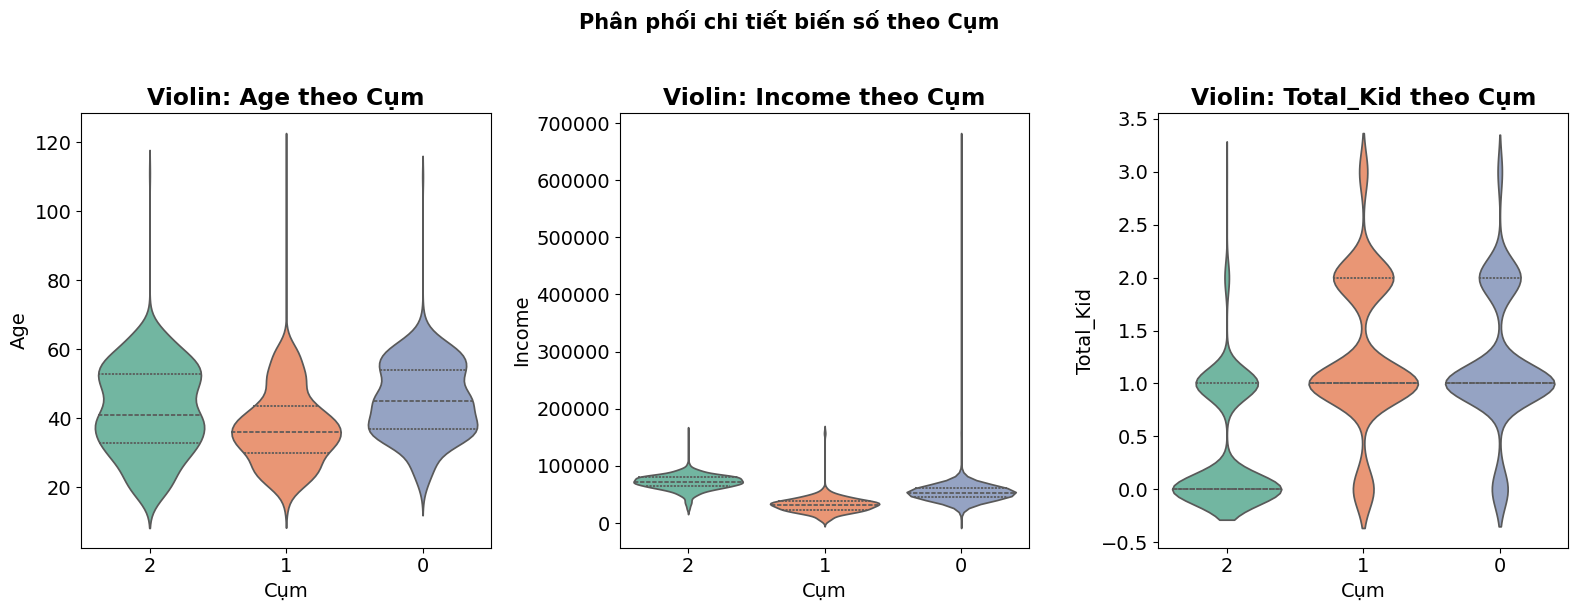

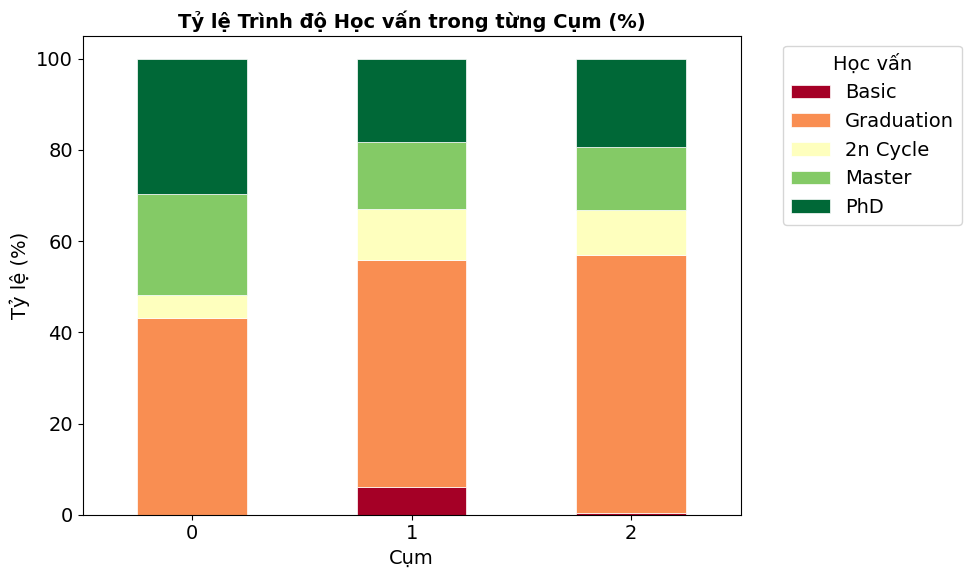

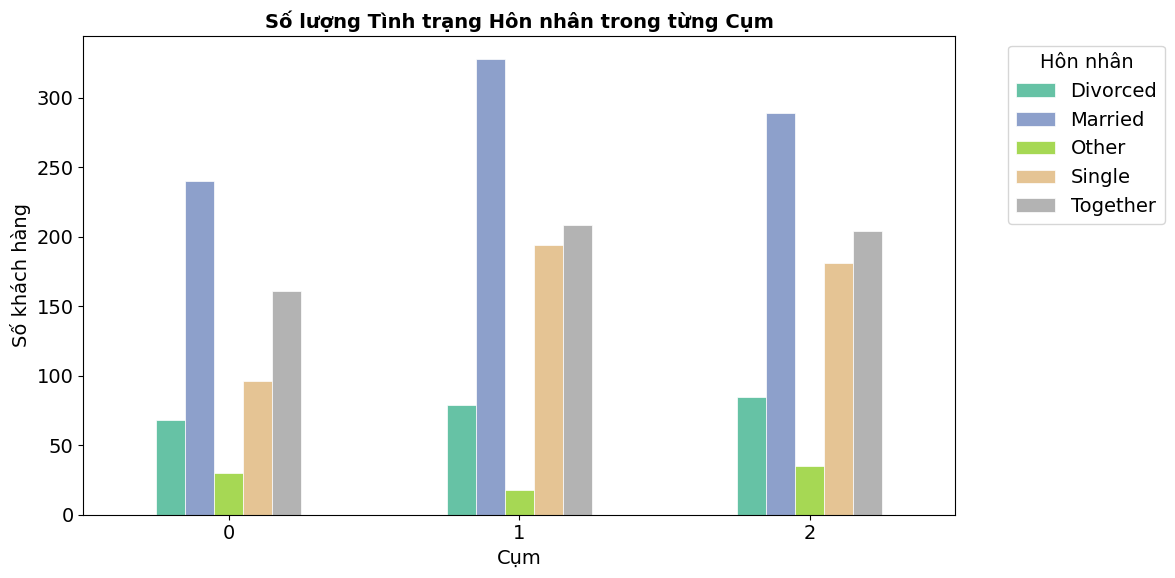

In [146]:
# ======================================================
# GẮN NHÃN CỤM VÀO DỮ LIỆU GỐC (CHƯA SCALE)
# ======================================================
df_analysis = df_collections.copy()
df_analysis['Cluster'] = cluster_labels.astype(str) 

# ======================================================
# 1. THỐNG KÊ MÔ TẢ TỪNG CỤM
# ======================================================
num_features  = ['Age', 'Income', 'Total_Kid']
cat_features  = ['Education', 'Marital_Status']

print("=" * 60)
print("THỐNG KÊ MÔ TẢ THEO CỤM")
print("=" * 60)
print(df_analysis.groupby('Cluster')[num_features].agg(['mean', 'median', 'std']).round(2))

# ======================================================
# 2. VIOLIN PLOT
# ======================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, num_features):
    sns.violinplot(data=df_analysis, x='Cluster', y=col,
                   hue='Cluster',       # <-- thêm hue
                   palette='Set2',      # <-- dùng tên palette thay dict
                   ax=ax, inner='quartile',
                   legend=False)
    ax.set_title(f'Violin: {col} theo Cụm', fontweight='bold')
    ax.set_xlabel('Cụm')

plt.suptitle('Phân phối chi tiết biến số theo Cụm', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# ======================================================
# 3. EDUCATION — Stacked Bar (tỷ lệ % từng trình độ trong cụm)
# ======================================================
edu_map_rev = {1:'Basic', 2:'Graduation', 3:'2n Cycle', 4:'Master', 5:'PhD'}
df_analysis['Education_Label'] = df_analysis['Education'].map(edu_map_rev)

edu_ct = (df_analysis.groupby(['Cluster', 'Education_Label'])
                      .size()
                      .unstack(fill_value=0))
edu_pct = edu_ct.div(edu_ct.sum(axis=1), axis=0) * 100

edu_order = ['Basic', 'Graduation', '2n Cycle', 'Master', 'PhD']
edu_pct = edu_pct.reindex(columns=edu_order, fill_value=0)

edu_pct.plot(kind='bar', stacked=True, figsize=(10, 6),
             colormap='RdYlGn', edgecolor='white', linewidth=0.5)
plt.title('Tỷ lệ Trình độ Học vấn trong từng Cụm (%)', fontsize=14, fontweight='bold')
plt.xlabel('Cụm')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Học vấn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ======================================================
# 4. MARITAL STATUS — Grouped Bar (số lượng tuyệt đối)
# ======================================================
marital_ct = (df_analysis.groupby(['Cluster', 'Marital_Status'])
                          .size()
                          .unstack(fill_value=0))

marital_ct.plot(kind='bar', figsize=(12, 6),
                colormap='Set2', edgecolor='white', linewidth=0.5)
plt.title('Số lượng Tình trạng Hôn nhân trong từng Cụm', fontsize=14, fontweight='bold')
plt.xlabel('Cụm')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=0)
plt.legend(title='Hôn nhân', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Chân dung khách hàng : 
- Cụm 0 : 

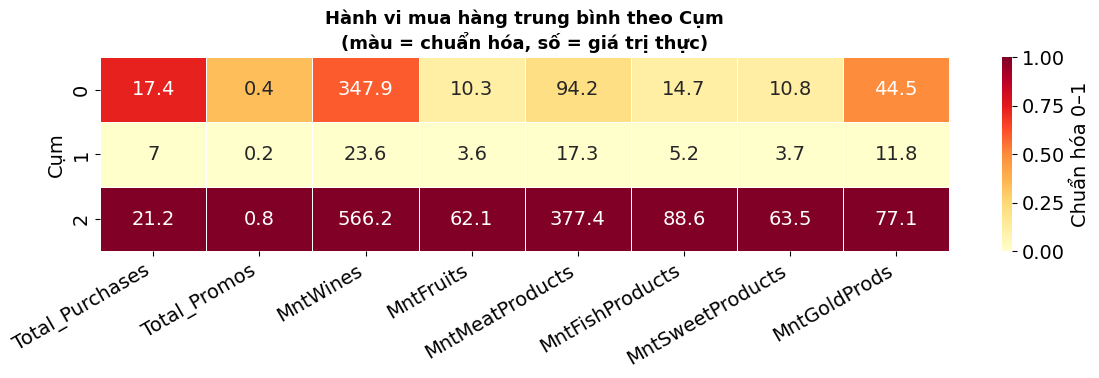

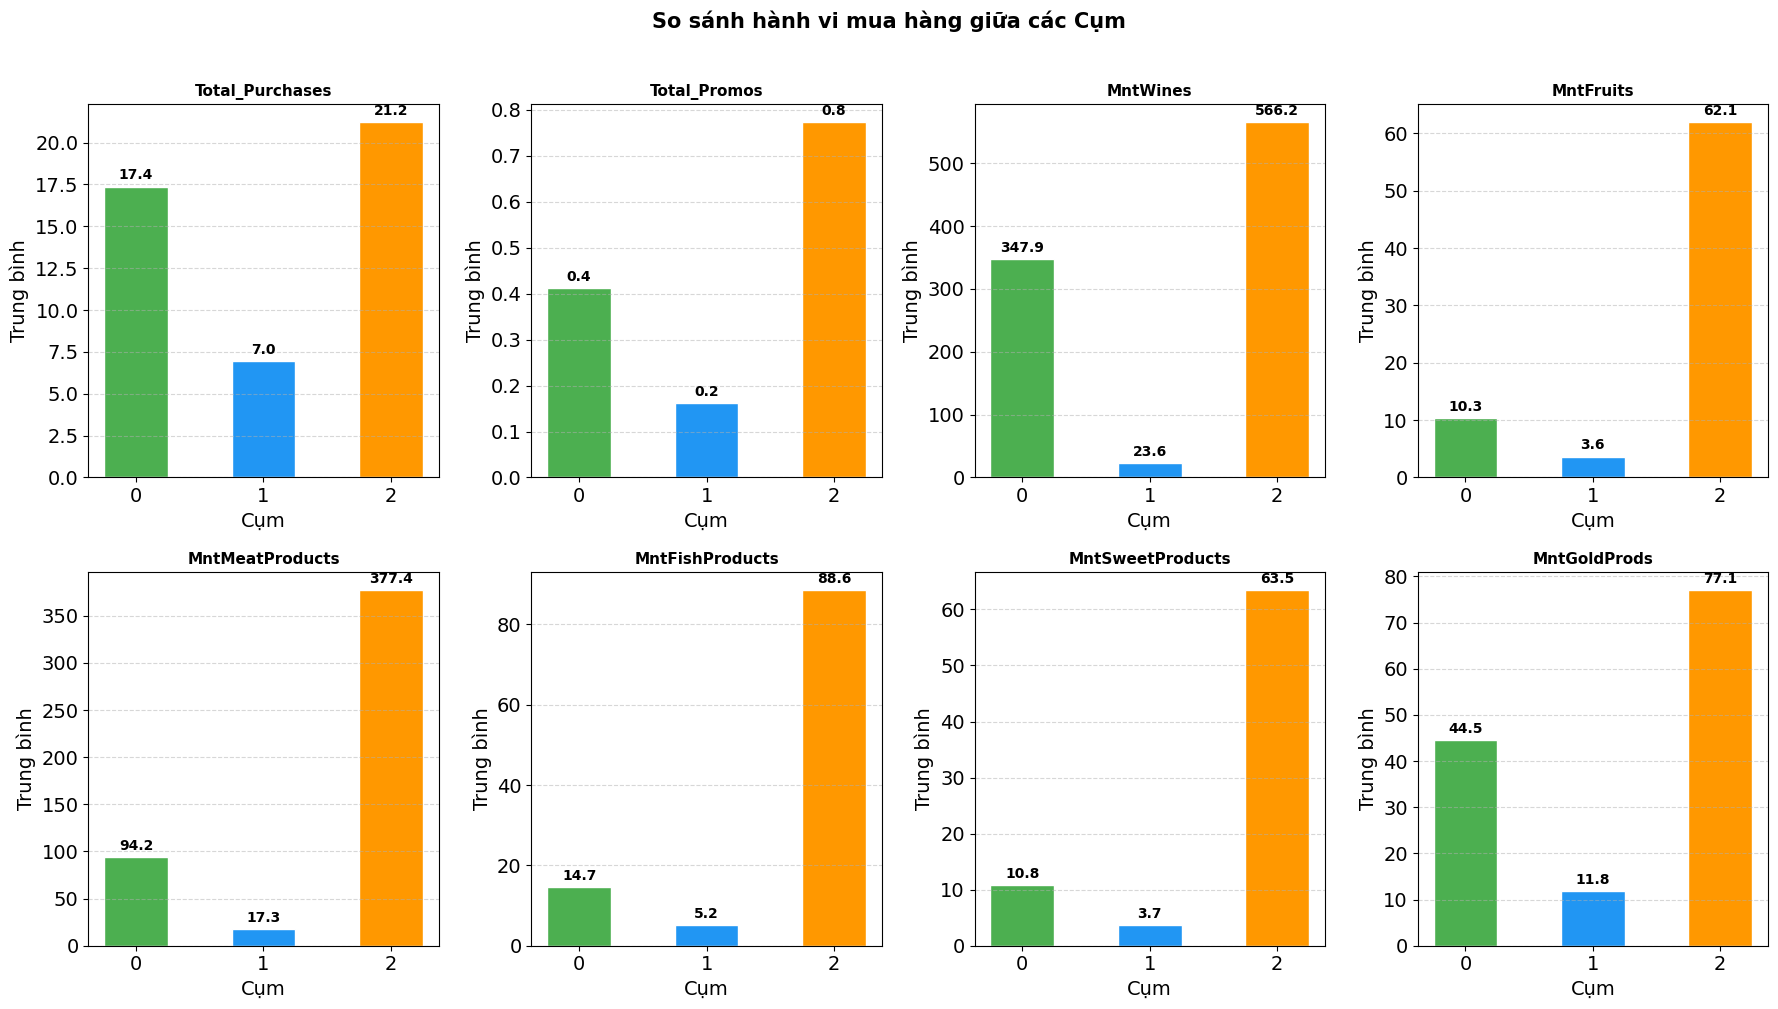


--- TRUNG BÌNH HÀNH VI MUA HÀNG THEO CỤM ---
         Total_Purchases  Total_Promos  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds
Cluster                                                                                                                      
0                   17.4           0.4     347.9       10.3             94.2             14.7              10.8          44.5
1                    7.0           0.2      23.6        3.6             17.3              5.2               3.7          11.8
2                   21.2           0.8     566.2       62.1            377.4             88.6              63.5          77.1


In [147]:
# ======================================================
# GẮN NHÃN CỤM VÀO DỮ LIỆU GỐC
# ======================================================
behavior_cols = ['Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 
                 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_behavior = df_collections[behavior_cols].copy()
df_behavior['Cluster'] = cluster_labels.astype(str)

# ======================================================
# 1. HEATMAP — Giá trị trung bình từng cụm
# ======================================================
heatmap_data = df_behavior.groupby('Cluster')[behavior_cols].mean().round(1)

# Chuẩn hóa 0-1 theo cột để màu sắc so sánh được
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_norm, 
            annot=heatmap_data,   # hiện số thực
            fmt='g',
            cmap='YlOrRd', 
            linewidths=0.5,
            cbar_kws={'label': 'Chuẩn hóa 0–1'})
plt.title('Hành vi mua hàng trung bình theo Cụm\n(màu = chuẩn hóa, số = giá trị thực)',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Cụm')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ======================================================
# 2. GROUPED BAR — So sánh trực tiếp từng chỉ số
# ======================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(behavior_cols):
    cluster_mean = df_behavior.groupby('Cluster')[col].mean()
    axes[i].bar(cluster_mean.index, cluster_mean.values,
                color=['#4CAF50', '#2196F3', '#FF9800'],
                edgecolor='white', width=0.5)
    
    # Hiện số trên đầu mỗi cột
    for x, v in zip(cluster_mean.index, cluster_mean.values):
        axes[i].text(x, v + max(cluster_mean)*0.02, f'{v:.1f}', 
                     ha='center', fontsize=10, fontweight='bold')
    
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Cụm')
    axes[i].set_ylabel('Trung bình')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('So sánh hành vi mua hàng giữa các Cụm', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ======================================================
# 3. IN BẢNG THỐNG KÊ TÓM TẮT
# ======================================================
print("\n--- TRUNG BÌNH HÀNH VI MUA HÀNG THEO CỤM ---")
print(heatmap_data.to_string())